In [1]:
from typing import Annotated

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage

from langgraph.graph import StateGraph, START, END  
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

from langgraph.types import interrupt, Command

from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage #base message is parent class for human message, ai messagen and system message

In [2]:
load_dotenv()

import os
key = os.getenv("GROQ_API_KEY")
model = ChatGroq(model="llama-3.3-70b-versatile", api_key=key)
model.invoke("hello how are you").content

"Hello. I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm always happy to chat and help with any questions or topics you'd like to discuss. How about you? How's your day going so far?"

In [3]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]  # add message is a reducer function telling not to overwrite the existing list, insted use add_message to append new messages


- **What it does:** The interrupt() function literally suspends the execution of the graph right at this line.

- **The Magic:** The graph doesn't just block the main thread like a standard Python input(). Instead, LangGraph effectively "goes to sleep." It saves the exact state of your application to a database (a checkpointer).

- **The Payload:** The dictionary you pass inside interrupt(...) is handed over to the human reviewer (perhaps rendered on a frontend UI). It gives them the exact context they need: What is the user asking? What do I need to approve?




- **what to send inside interrupt**
Think of the interrupt() function as a messenger. When the graph pauses, it needs to hand a "sticky note" to the human outside the graph so the human knows why the graph paused.

LangGraph does not care what is written on that sticky note. You can pass any data into interrupt(), as long as it is standard, saveable data (like a string, a list, or a dictionary).

In [4]:
#simple chat node BUT with HITL

def chatnode(state:ChatState):

    decision = interrupt({
        "type":"approval",
        "reason":"model is about to answer the user question",
        "questions": state["messages"][-1].content,
        "instruction":"approve this question? yes/no"
    })

    if decision["approved"] == "no":
        return {"messages": [AIMessage(content="not approved...")]}
    
    else:
        response = model.invoke(state["messages"])
        return {"messages": [response]}

In [5]:
#making of the graph

graph = StateGraph(ChatState)

graph.add_node("chat", chatnode)

graph.add_edge(START, "chat")
graph.add_edge("chat", END)


#checkpointers are required for interupts
checkpointer = MemorySaver()

app = graph.compile(checkpointer=checkpointer) #compile the graph

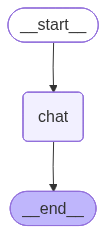

In [6]:
app

### Implementation

In [7]:
 #creating new thread id for this conversation
config = {"configurable": {"thread_id" : "1234"}}


#step -1 user ask the question
initial_state_input = {
    "messages": [
        ("user","what is the iran important country")
    ]
}


#invoke the graph for the first time
result = app.invoke(initial_state_input, config=config)

The awesome thing about LangChain and LangGraph is that they are smart enough to understand tuples as a shortcut.

Behind the scenes, LangGraph will automatically convert your tuple into:\n/n
**HumanMessage(content="what is the iran important country")**

In [8]:
result # we see user message and then flow reached chatnode, but it had the interupt() function and it has all the interrupt message

{'messages': [HumanMessage(content='what is the iran important country', additional_kwargs={}, response_metadata={}, id='d743eadb-54b9-454e-bfc9-d7dd81fcf421')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'model is about to answer the user question', 'questions': 'what is the iran important country', 'instruction': 'approve this question? yes/no'}, id='8f54e400171ac42d4f6037110f4d2c30')]}

In [9]:
#extracting the interrupt message
message = result["__interrupt__"][0].value
message

{'type': 'approval',
 'reason': 'model is about to answer the user question',
 'questions': 'what is the iran important country',
 'instruction': 'approve this question? yes/no'}

In [10]:
# then we go at frontend show this message and ask if yes or no?
user_input = input(f"backend message: {message} \n approve this ques.? (yes/no)")

In [11]:
# resume the graph with the approval decision
final_reault = app.invoke(
    Command(resume={"approved": user_input}), # by command we tell the langgraph not start from complete start, wake up the node that is currently sleeping and give this data
    config=config
)

In [12]:
print(final_reault)

{'messages': [HumanMessage(content='what is the iran important country', additional_kwargs={}, response_metadata={}, id='d743eadb-54b9-454e-bfc9-d7dd81fcf421'), AIMessage(content="Iran is indeed a significant country in the world, and its importance can be understood from several perspectives. Here are some reasons why Iran is considered an important country:\n\n1. **Strategic Location**: Iran is situated in the Middle East, a region of great strategic importance. It borders several countries, including Iraq, Turkey, Afghanistan, and Pakistan, making it a crucial player in regional politics and security.\n2. **Energy Resources**: Iran is the world's fourth-largest oil producer and has the second-largest natural gas reserves. Its energy resources make it a vital player in the global energy market, and its oil exports are a significant contributor to its economy.\n3. **Large Population**: With a population of over 83 million people, Iran is the 17th most populous country in the world. It

### what happens after interrupt():
- pause the current execution
- save the state via checkpointers
- prepare a message from interrupt 
- send message to frontend


### at frontend:
- revice the interrupt message
- take the user input
- invoke BUT with command
- then langgrph continues from where we left but with additional data

## Advanced Example of HITL

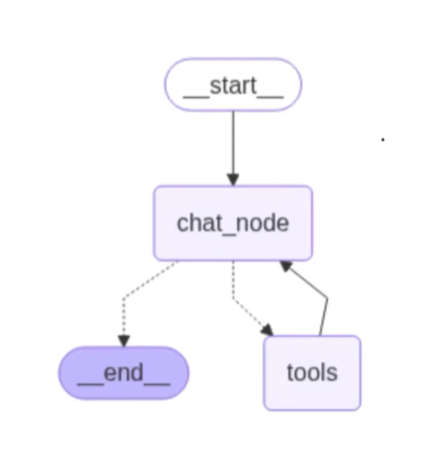

### chatbot will have tools to fetch the stock price and buy stock

In [13]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages # this is reducer fn

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
import requests

load_dotenv()

True

In [15]:
load_dotenv()

import os
key = os.getenv("GROQ_API_KEY")
model = ChatGroq(model="llama-3.3-70b-versatile", api_key=key)
model.invoke("hello how are you").content

"Hello. I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm always happy to chat and help with any questions or topics you'd like to discuss. How about you? How's your day going so far?"

In [16]:
@tool
def get_stock_price(symbol:str) -> dict:
    """Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL."""

    url = (
        "https://www.alphavantage.co/query"
        f"?function=GLOBAL_QUOTE&symbol={symbol}&apikey=PP8KSVAUL6E9PGPY"
    )
    r = requests.get(url)
    return r.json()

In [18]:
@tool
def purchase_stock(symbol: str, quantity: int) -> dict:
    """Simulate purchasing a given quantity of a stock symbol.

    HUMAN-IN-THE-LOOP:
    Before confirming the purchase, this tool will interrupt
    and wait for a human decision ("yes" / anything else)."""


    decision = interrupt(f"Approve buying {quantity} shrares of {symbol}.") # this pause the graph and give message to frontend


    if isinstance(decision, str) and decision.lower() == "yes":
        return {
            "status": "success",
            "message": f"Purchase order placed for {quantity} shares of {symbol}.",
            "symbol": symbol,
            "quantity": quantity,
        }
    
    else:
        return {
            "status": "cancelled", 
            "message": f"Purchase of {quantity} shares of {symbol} was declined by human.",
            "symbol": symbol,
            "quantity": quantity,
        }

In [19]:
tools = [get_stock_price, purchase_stock]
llm_with_tools = model.bind_tools(tools)

In [20]:
#state
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


In [21]:
#nodes
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)

In [22]:
#checkpointers
memory = MemorySaver()

In [23]:
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chat_node")

graph.add_conditional_edges("chat_node", tools_condition)
graph.add_edge("tools", "chat_node")

chatbot = graph.compile(checkpointer=memory)

In [ ]:
if __name__ == "__main__":
    
    # Use a fixed thread_id so the conversation is persisted in memory
    thread_id = "demo-thread"

    while True:
        user_input = input("You: ")
        if user_input.lower().strip() in {"exit", "quit"}:
            print("Goodbye!")
            break

        # Build initial state for this turn
        state = {"messages": [HumanMessage(content=user_input)]}

        # Run the graph (may hit an interrupt)
        result = chatbot.invoke(
            state,
            config={"configurable": {"thread_id": thread_id}},
        )

        # Check for HITL interrupt from purchase_stock
        interrupts = result.get("__interrupt__", [])

        if interrupts:
            # Our interrupt payload is the string we passed to interrupt(...)
            prompt_to_human = interrupts[0].value
            print(f"HITL: {prompt_to_human}")
            decision = input("Your decision: ").strip().lower()

            # Resume graph with the human decision ("yes" / "no" / whatever)
            result = chatbot.invoke(
                Command(resume=decision),
                config={"configurable": {"thread_id": thread_id}},
            )

        # Get the latest message from the assistant
        messages = result["messages"]
        last_msg = messages[-1]
        print(f"Bot: {last_msg.content}\n")

Bot: The current stock price of Tesla is $385.95.

HITL: Approve buying 5 shrares of TSLA.
Bot: Your purchase order for 5 shares of Tesla (TSLA) has been successfully placed.

HITL: Approve buying 5 shrares of TSLA.
Bot: Purchase of 5 shares of Tesla (TSLA) has been declined.

